# 01 - Video to Frames Pipeline
## Bradford Bulls - AI Sponsorship Exposure Valuation System

**Pipeline:**
1. Download video (YouTube URL or local file)
2. Extract metadata (FPS, resolution, duration)
3. Smart 3-layer frame sampling (L1: temporal → L2: scene change → L3: player presence)
4. Save frames with timestamp mapping
5. Filter for clear player visibility
6. Export frames ready for annotation

## 1. Setup & Install Dependencies

In [1]:
# Install dependencies (run once)
# !pip install -r ../requirements.txt

# If on macOS and yt-dlp not installed:
# !brew install yt-dlp

In [2]:
import sys
sys.path.insert(0, "..")

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import (
    DEVICE, FRAMES_DIR, FRAMES_CLEAR_DIR, METADATA_DIR, 
    VIDEOS_DIR, OUTPUT_DIR, TARGET_FPS
)
from src.video_pipeline import load_video, download_youtube, get_video_metadata
from src.frame_sampler import FrameSampler
from src.player_filter import PlayerVisibilityFilter

print(f"Device: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR}")

[Device] Using: cpu (CPU)
Device: cpu
Output directory: c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output


## 2. Download Video & Extract Metadata

Set the video source below. Can be:
- **YouTube URL**: `"https://www.youtube.com/watch?v=..."`
- **Local file path**: `"/path/to/video.mp4"`

In [3]:
# ============================================================
# SET YOUR VIDEO SOURCE HERE
# ============================================================
VIDEO_SOURCE = "https://www.youtube.com/watch?v=Yly5ELzUmbw"

# Load video (downloads if YouTube URL)
video_meta = load_video(VIDEO_SOURCE)
print(video_meta)

[Download] Downloading from: https://www.youtube.com/watch?v=Yly5ELzUmbw
[Download] Format: bestvideo[height<=1080]+bestaudio/bestvideo+bestaudio/best[height<=1080]/best
[Download] ffmpeg: C:\Users\Admin\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffmpeg.exe
[Download] Saved to: c:\Users\Admin\Desktop\bradford_bulls\output\videos\Full Game ｜ London Broncos vs Bradford Bulls.mp4
[Metadata]
Video: Full Game ｜ London Broncos vs Bradford Bulls
  Path:       c:\Users\Admin\Desktop\bradford_bulls\output\videos\Full Game ｜ London Broncos vs Bradford Bulls.mp4
  Duration:   87.2 min (5234s)
  Resolution: 1280x720
  FPS:        30.0
  Frames:     157,017
Video: Full Game ｜ London Broncos vs Bradford Bulls
  Path:       c:\Users\Admin\Desktop\bradford_bulls\output\videos\Full Game ｜ London Broncos vs Bradford Bulls.mp4
  Duration:   87.2 min (5234s)
  Resolution: 1280x720
  FPS:        30.0
  Frames:     157,017


## 3. Preview: First Frame of the Video

Quick sanity check to make sure video loaded correctly.

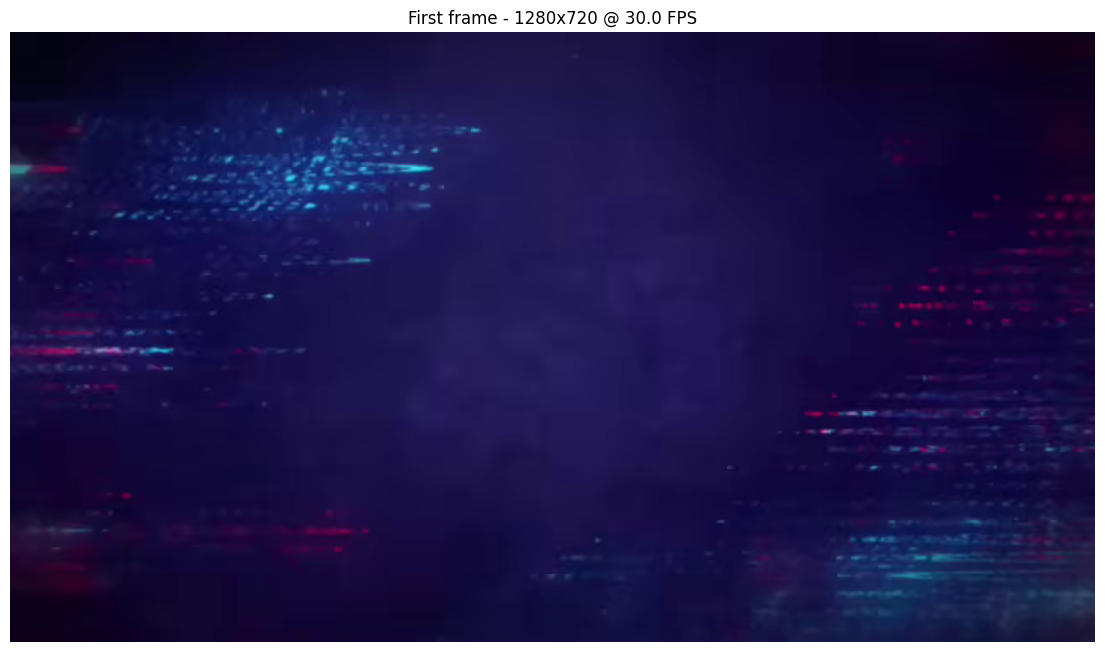

In [4]:
# Preview first frame
cap = cv2.VideoCapture(str(video_meta.file_path))
ret, first_frame = cap.read()
cap.release()

if ret:
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"First frame - {video_meta.width}x{video_meta.height} @ {video_meta.fps} FPS")
    plt.axis("off")
    plt.show()
else:
    print("ERROR: Could not read first frame")

## 4. Smart Frame Sampling (L1 + L2 + L3)

Extract frames using 3-layer filtering:
- **L1 - Temporal**: Reduce from original FPS to ~2 FPS
- **L2 - Scene Change**: Skip frames that are visually identical (pHash + SSIM)
- **L3 - Player Presence**: Only keep frames with at least 1 person detected (YOLOv8)

Each frame is saved with its timestamp so it can be traced back to the exact video position.

**Tip:** For a quick test run, set `max_frames=100` to limit output. Remove it for full processing.

In [5]:
# Initialize frame sampler
sampler = FrameSampler(
    target_fps=2,          # L1: extract 2 frames per second
    phash_threshold=10,    # L2: perceptual hash difference threshold
    ssim_threshold=0.92,   # L2: structural similarity threshold
    person_confidence=0.5, # L3: min confidence for person detection
    min_persons=1,         # L3: at least 1 person in frame
    enable_l2=True,        # Enable scene change detection
    enable_l3=True,        # Enable player presence filter
)

# Run frame extraction
# Set max_frames=100 for quick test, remove for full video
frames_index_csv = sampler.extract_frames(
    video_meta,
    output_dir=FRAMES_DIR,
    metadata_dir=METADATA_DIR,
    max_frames=None,  # Set to 100 for testing
)


SMART FRAME SAMPLING
  Video:         Full Game ｜ London Broncos vs Bradford Bulls
  Original:      157,017 frames @ 30.0 FPS
  L1 Temporal:   1 frame every 15 frames (~2 FPS) → ~10,467 frames
  L2 Scene:      ON (pHash>10, SSIM<0.92)
  L3 Person:     ON (conf>0.5, min=1)



Extracting frames:   0%|          | 0/157017 [00:00<?, ?frame/s]

[L3] Loading YOLOv8 model for person detection...


Extracting frames: 100%|██████████| 157017/157017 [38:42<00:00, 67.60frame/s]


SAMPLING RESULTS
  Total frames:     157,017
  After L1 (temp):  10,468 (6.7%)
  After L2 (scene): 9,985 (removed 483 similar frames)
  After L3 (person): 9,907 (removed 78 frames without players)
  Final saved:      9,907 frames
  Reduction:        93.7%
  Saved to:         c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\frames
  Index CSV:        c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\metadata\frames_index.csv



## 5. Review Extracted Frames

Check the frames index CSV and preview some extracted frames.

In [6]:
# Load and display the frames index
df = pd.read_csv(frames_index_csv)
print(f"Total extracted frames: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 10 frames:")
df.head(10)

Total extracted frames: 9907

Columns: ['frame_id', 'original_frame_num', 'timestamp_sec', 'timestamp_hms', 'source_video', 'fps_original', 'persons_detected', 'max_person_area_ratio', 'filename']

First 10 frames:


,frame_id,original_frame_num,timestamp_sec,timestamp_hms,source_video,fps_original,persons_detected,max_person_area_ratio,filename
0,1,135,4.5,00m04s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,7,0.0099,frame_000001_00m04s.jpg
1,2,150,5.0,00m05s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,5,0.0135,frame_000002_00m05s.jpg
2,3,165,5.5,00m05s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,6,0.0149,frame_000003_00m05s.jpg
3,4,180,6.0,00m06s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,6,0.0152,frame_000004_00m06s.jpg
4,5,195,6.5,00m06s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,6,0.0162,frame_000005_00m06s.jpg
5,6,210,7.0,00m07s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,7,0.0178,frame_000006_00m07s.jpg
6,7,225,7.5,00m07s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,6,0.0183,frame_000007_00m07s.jpg
7,8,240,8.0,00m08s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,5,0.0187,frame_000008_00m08s.jpg
8,9,255,8.5,00m08s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,5,0.0151,frame_000009_00m08s.jpg
9,10,270,9.0,00m09s,Full Game ｜ London Broncos vs Bradford Bulls.mp4,30.0,5,0.0150,frame_000010_00m09s.jpg


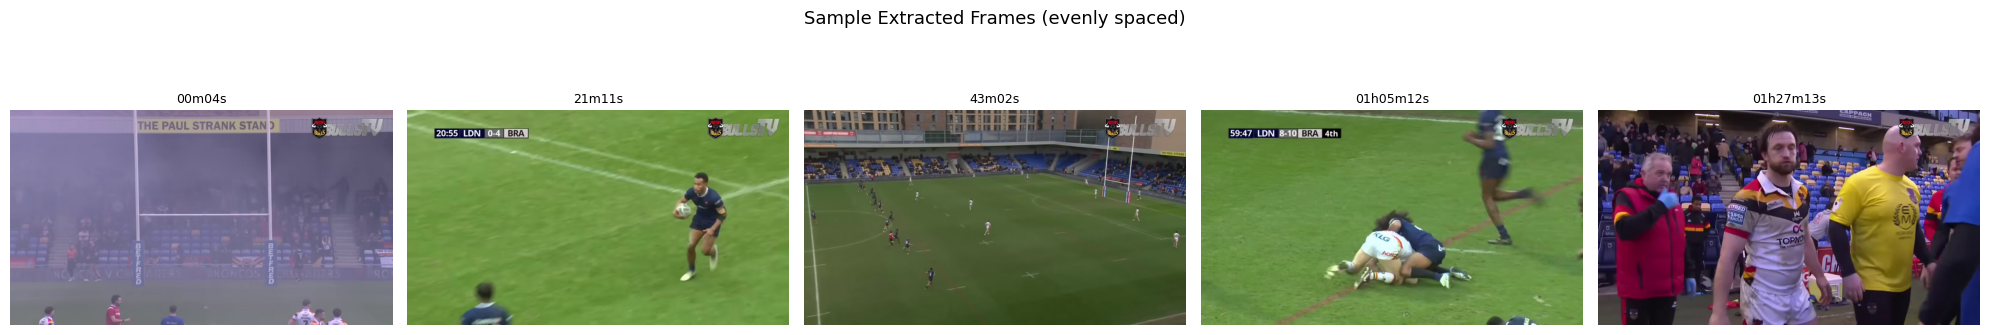

Total frames saved: 9907


In [7]:
# Preview a grid of extracted frames
frame_files = sorted(FRAMES_DIR.glob("frame_*.jpg"))
sample_indices = [0, len(frame_files)//4, len(frame_files)//2, 3*len(frame_files)//4, -1]
sample_frames = [frame_files[i] for i in sample_indices if i < len(frame_files)]

fig, axes = plt.subplots(1, len(sample_frames), figsize=(20, 4))
for ax, fpath in zip(axes, sample_frames):
    img = cv2.imread(str(fpath))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fpath.stem.split("_", 2)[-1], fontsize=9)  # Show timestamp
    ax.axis("off")
plt.suptitle("Sample Extracted Frames (evenly spaced)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total frames saved: {len(frame_files)}")

## 6. Player Visibility Filtering

From the extracted frames, select only those where players are **clearly visible**:
- Player bounding box >= 3% of frame area (not too far from camera)
- Sharpness score >= 50 (not motion-blurred)

Output goes to `frames_clear/` — these are the frames ready for annotation.

In [8]:
# Initialize player visibility filter
player_filter = PlayerVisibilityFilter(
    min_area_ratio=0.03,    # Player must be >= 3% of frame
    min_sharpness=50.0,     # Minimum sharpness score
    person_confidence=0.5,  # YOLOv8 confidence threshold
)

# Run filtering
filter_results = player_filter.filter_frames(
    frames_dir=FRAMES_DIR,
    output_dir=FRAMES_CLEAR_DIR,
    metadata_dir=METADATA_DIR,
    frames_index_csv=frames_index_csv,
)


PLAYER VISIBILITY FILTERING
  Input frames:     9907
  Min area ratio:   3.0%
  Min sharpness:    50.0



Filtering frames:   0%|          | 1/9907 [00:00<18:08,  9.10it/s]

[Filter] Loading YOLOv8 model...


Filtering frames: 100%|██████████| 9907/9907 [06:19<00:00, 26.08it/s]



FILTERING RESULTS
  Input frames:      9907
  Clear players:     6476 (65.4%)
  Rejected:          3431
  Output dir:        c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\frames_clear
  Filter details:    c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\metadata\frames_filter_results.csv



## 7. Review Filtered Frames (Ready for Annotation)

Frames ready for annotation: 6476


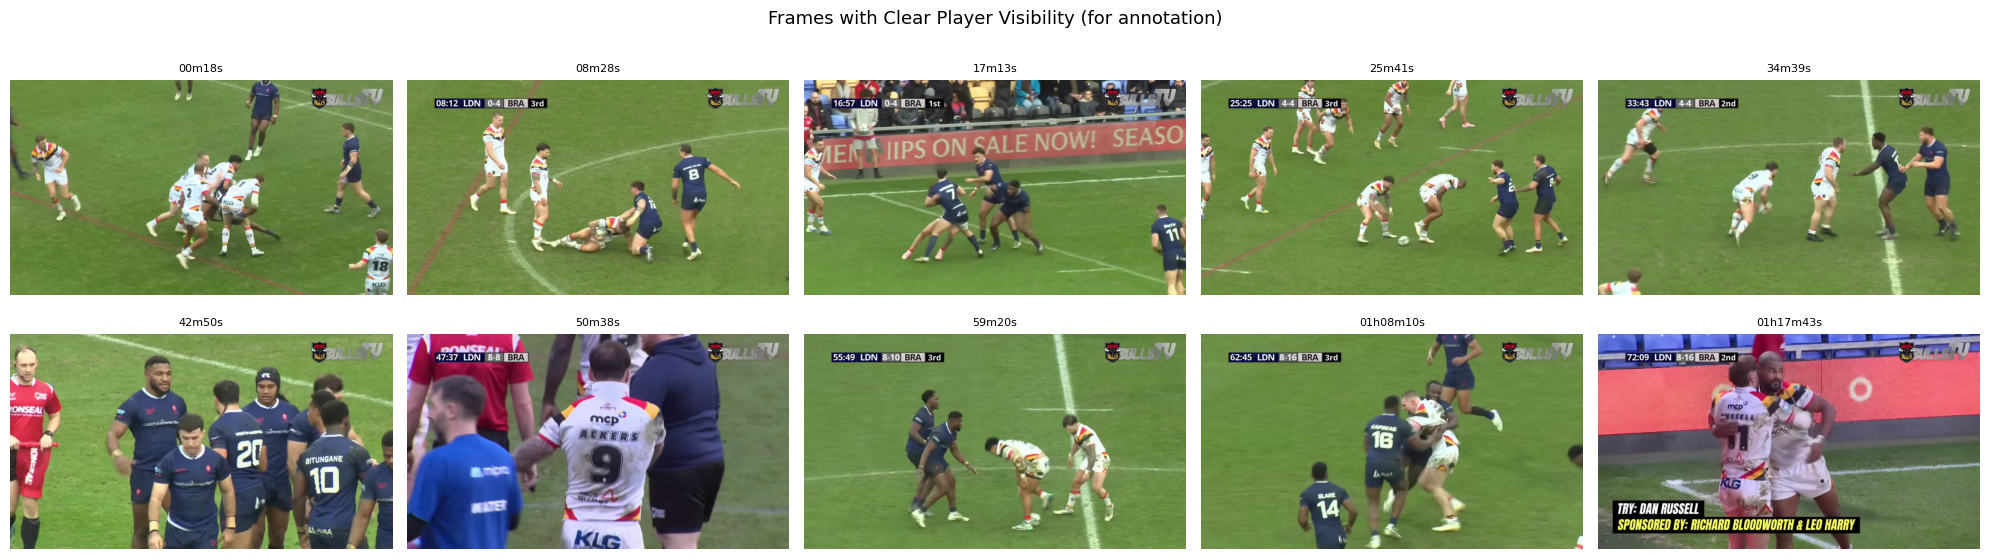

In [9]:
# Preview frames that passed the visibility filter
clear_frames = sorted(FRAMES_CLEAR_DIR.glob("frame_*.jpg"))
print(f"Frames ready for annotation: {len(clear_frames)}")

# Show a grid of clear frames
n_preview = min(10, len(clear_frames))
if n_preview > 0:
    step = max(1, len(clear_frames) // n_preview)
    samples = [clear_frames[i * step] for i in range(n_preview) if i * step < len(clear_frames)]
    
    rows = 2
    cols = (len(samples) + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 6))
    axes = axes.flatten()
    
    for i, fpath in enumerate(samples):
        img = cv2.imread(str(fpath))
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(fpath.stem.split("_", 2)[-1], fontsize=8)
        axes[i].axis("off")
    
    # Hide unused axes
    for j in range(len(samples), len(axes)):
        axes[j].axis("off")
    
    plt.suptitle("Frames with Clear Player Visibility (for annotation)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No frames passed the filter. Try adjusting thresholds.")

## 8. Summary Statistics

In [10]:
# Summary
df_index = pd.read_csv(frames_index_csv)
clear_count = len(list(FRAMES_CLEAR_DIR.glob("frame_*.jpg")))

print("=" * 60)
print("PHASE 1 COMPLETE - SUMMARY")
print("=" * 60)
print(f"  Video:                {video_meta.title}")
print(f"  Duration:             {video_meta.duration_sec / 60:.1f} min")
print(f"  Original frames:      {video_meta.total_frames:,}")
print(f"  After smart sampling: {len(df_index):,} frames")
print(f"  Clear player frames:  {clear_count:,} frames")
print(f"  Reduction:            {(1 - clear_count / video_meta.total_frames) * 100:.1f}%")
print(f"")
print(f"  Frames directory:     {FRAMES_DIR}")
print(f"  Clear frames dir:     {FRAMES_CLEAR_DIR}")
print(f"  Metadata CSV:         {frames_index_csv}")
print("=" * 60)
print(f"\nNext step: Open 02_annotation_roboflow.ipynb to annotate logos on these frames.")

PHASE 1 COMPLETE - SUMMARY
  Video:                Full Game ｜ London Broncos vs Bradford Bulls
  Duration:             87.2 min
  Original frames:      157,017
  After smart sampling: 9,907 frames
  Clear player frames:  6,476 frames
  Reduction:            95.9%

  Frames directory:     c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\frames
  Clear frames dir:     c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\frames_clear
  Metadata CSV:         c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\metadata\frames_index.csv

Next step: Open 02_annotation_roboflow.ipynb to annotate logos on these frames.
